In [1]:
# защита от падения ядра IPython
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from pathlib import Path
import pandas as pd
from scipy.signal import ShortTimeFFT
from scipy.signal.windows import blackman
import shutil

from src.data_preprocessing import (
    read_oscilloscope_data,
    segment_signal,
    perform_fft_on_segments,
    plot_random_segments,
    plot_manual_fft_as_full_spectrogram,
    plot_full_scipy_spectrogram,
    plot_spectrogram_samples,
    spectrogram_samples_from_file,
    spectrogram_samples_manual,
    spectrogram_samples_using_scipy,
    numpy_to_pillow,
    scipy_to_pillow
)

## Обучение нейросетей

Набираем датасет.

Для engine_1:

In [ ]:
def create_engine_1_data(input_path: str,
                          count_1d: int = 2000, 
                          count_2d: int = 8000, 
                          output_path: str = '../data/processed',
                          input_data_type: str = 'txt',
                          segment_length=10000,
                          f_sampling=10000,
                          step=20,
                          apply_window='blackman'):
    '''
    Function for collecting 1D-spectra and spectrograms

    Parameters:
    - input_path: raw data folder
    - count_1d: number of 1D-spectra for each signal type
    - count_2d: number of spectrograms for each signal type
    - output_path: processed data folder (inside output_path, a folder named 'ours_FFT' 
    - input_data_type: using .txt or .csv data
    for 1D-spectra and a folder named 'ours_spectrogram' for spectrograms are created)
    '''
    if os.path.isdir(output_path):
        shutil.rmtree(output_path)
    os.makedirs(output_path)
    for input_file in Path(input_path).rglob(f'*.{input_data_type}'):
        if input_data_type == 'txt':
            open(f'{output_path}/Anomalous.csv', 'a').close()
            df = read_oscilloscope_data(
                file_path=input_file,
                output_path=f'{output_path}/Anomalous.csv'
            )
            some_signal = df['Data'].to_numpy()
        else:
            df = pd.read_csv(input_file)
            some_signal = df['1'].fillna(0).to_numpy()
        some_signal_mean = np.mean(some_signal)
        some_signal -= some_signal_mean
        segments = segment_signal(some_signal, segment_length=segment_length, step=step, apply_window=apply_window)[:count_1d]
        fft_segments, freqs = perform_fft_on_segments(segments, f_sampling=f_sampling, db=True, cutoff_freq=250)
        os.makedirs(f"{output_path}/{input_file.name}/ours_FFT")
        os.makedirs(f"{output_path}/{input_file.name}/ours_spectrogram")
        for idx in range(len(fft_segments)):
            np.save(f"{output_path}/{input_file.name}/ours_FFT/{idx}.npy", fft_segments[idx])
        signal_samples = spectrogram_samples_manual(some_signal, 3, count_2d, f_sampling=f_sampling)
        for idx in range(len(signal_samples)):
            np.save(f"{output_path}/{input_file.name}/ours_spectrogram/{idx}_FFT.npy", signal_samples[idx][3])

create_engine_1_data(input_path='../dataset/engine_1', 
                     output_path='../data/processed_engine_1')

Для engine_2:

In [11]:
def create_engine_2_data(input_path: str,
                          count_1d: int = 2000, 
                          count_2d: int = 2000, 
                          output_path: str = '../data/processed',
                          input_data_type: str = 'csv',
                          segment_length=4098,
                          f_sampling=4098,
                          step=20,
                          apply_window='blackman'):
    if os.path.isdir(output_path):
        shutil.rmtree(output_path)
    os.makedirs(output_path)
    engine_2_signals = Path(input_path).glob('*')
    for load_folder in engine_2_signals:
        phases = load_folder.glob("*")
        for phase_folder in phases:
            signal_file = list(phase_folder.glob(f'*.{input_data_type}'))[0]
            if input_data_type == 'csv':
                df = pd.read_csv(signal_file)
                engine_2_signal = df['1'].fillna(0).to_numpy()
            else:
                open(f'{output_path}/Anomalous.csv', 'a').close()
                df = read_oscilloscope_data(
                    file_path=signal_file,
                    output_path=f'{output_path}/Anomalous.csv'
                )
                engine_2_signal = df['Data'].to_numpy()
            engine_2_signal_mean = np.mean(engine_2_signal)
            engine_2_signal -= engine_2_signal_mean
            engine_2_segments = segment_signal(engine_2_signal, 
                                               segment_length=segment_length, 
                                               step=step, 
                                               apply_window=apply_window)[:count_1d]
            engine_2_fft, engine_2_freqs = perform_fft_on_segments(engine_2_segments, 
                                                                   f_sampling=f_sampling, 
                                                                   db=True, 
                                                                   cutoff_freq=250)
            full_output_path = f'{output_path}/{load_folder.stem}/{phase_folder.stem}/{signal_file.stem}'
            os.makedirs(f"{full_output_path}/ours_FFT")
            os.makedirs(f"{full_output_path}/ours_spectrogram")
            for idx in range(len(engine_2_segments)):
                np.save(f"{full_output_path}/ours_FFT/{idx}.npy", engine_2_fft[idx])
            signal_samples = spectrogram_samples_manual(engine_2_signal, 3, count_2d, f_sampling=f_sampling)
            for idx in range(len(signal_samples)):
                np.save(f"{full_output_path}/ours_spectrogram/{idx}_FFT.npy", signal_samples[idx][3])

In [12]:
create_engine_2_data(input_path='../dataset/engine_2/experiment_1/current', 
                     output_path='../data/processed_engine_2')

In [3]:
import torch
from torch.utils.data import Dataset, DataLoader


class FFTDataset(Dataset):
    '''
    Dataset class for 1D-spectra and spectrograms
    '''
    def __init__(self, files, labels):
        '''
        Parameters:
        - files: list of *.npy files
        - labels: list of class labels
        '''
        self.data = []
        self.labels = []
        for filepath in files:
            self.data.append(torch.FloatTensor(np.load(filepath)).unsqueeze(0))
        self.labels = labels

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        return self.data[index], self.labels[index]

In [4]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [5]:
from typing import List, Union
import random
from sklearn.model_selection import train_test_split


# для бинарной классификации обозначим "здоровый" сигнал как 0, сигналы с ошибками как 1
# и загрузим все ошибочные сигналы в датасет в равных долях 
def get_binary_dataloaders(healthy_folder: str,
                           fault_folders_list: List[str],
                           healthy_samples: Union[int, None] = None,
                           test_size: float = 0.25,
                           seed: int = 42,
                           batch_size = 32) -> List[DataLoader]:
    '''
    Function for creating dataloaders for binary classification

    Parameters:
    - healty_folder: folder containing "healty" signal *.npy files 
    - fault_folders_list: list of folders containing faulty signal *.npy files
    - healthy_samples: number of samples for "healthy" signal

    Returns:
    - list of dataloaders is in order: train, val, test
    '''
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    fft_list = list(Path(healthy_folder).rglob('*.npy'))
    labels_list = [0 for _ in range(len(fft_list))]
    if healthy_samples is not None:
        fft_list = fft_list[:healthy_samples]
        labels_list = labels_list[:healthy_samples]
    list_part = len(fft_list) // len(fault_folders_list)
    for signal_type in fault_folders_list:
        fault_list = list(Path(signal_type).rglob('*.npy'))[:list_part]
        fft_list += fault_list
        labels_list += [1 for _ in range(len(fault_list))]
    Xtrain, Xtest, ytrain, ytest = train_test_split(fft_list, labels_list, random_state=seed, test_size=test_size)
    Xtrain, Xval, ytrain, yval = train_test_split(Xtrain, ytrain, random_state=seed, test_size=test_size)
    train_dataset = FFTDataset(Xtrain, ytrain)
    val_dataset = FFTDataset(Xval, yval)
    test_dataset = FFTDataset(Xtest, ytest)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    return train_loader, val_loader, test_loader

# в мультиклассовой классификации каждый сигнал - отдельный класс
def get_multiclass_dataloaders(folders_list: List[str],
                               all_data_samples: Union[int, None] = None,
                               test_size: float = 0.25,
                               seed: int = 42,
                               batch_size = 32) -> List[DataLoader]:
    '''
    Function for creating dataloaders for multiclass classification

    Parameters:
    - folders_list: list of folders containing *.npy files of different classes
    - all_data_samples: number of data samples for each class

    Returns:
    - list of dataloaders is in order: train, val, test
    '''
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    fft_list = []
    labels_list = []
    for i, signal_type in enumerate(folders_list):
        class_list = list(Path(signal_type).rglob('*.npy'))
        if all_data_samples is not None:
            class_list = class_list[:all_data_samples]
        fft_list += class_list
        labels_list += [i for _ in range(len(class_list))]
    Xtrain, Xtest, ytrain, ytest = train_test_split(fft_list, labels_list, random_state=seed, test_size=test_size)
    Xtrain, Xval, ytrain, yval = train_test_split(Xtrain, ytrain, random_state=seed, test_size=test_size)
    train_dataset = FFTDataset(Xtrain, ytrain)
    val_dataset = FFTDataset(Xval, yval)
    test_dataset = FFTDataset(Xtest, ytest)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    return train_loader, val_loader, test_loader

# каждый сигнал имеет метку класса, которую определил пользователь
def get_manual_labeled_dataloaders(folders_list: List[str],
                                   labels_match_list: List[int],
                                   samples_count_list: List[int],
                                   test_size: float = 0.25,
                                   seed: int = 42,
                                   batch_size = 32) -> List[DataLoader]:
    '''
    Function for creating dataloaders for multiclass classification

    Parameters:
    - folders_list: list of folders containing *.npy files of different classes
    - labels_match_list: list of labels for each signal
    - samples_count_list: list of number of data samples for each signal (None if we want to use all data)

    Returns:
    - list of dataloaders is in order: train, val, test
    '''
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    fft_list = []
    labels_list = []
    for folder, label, samples_count in zip(folders_list, labels_match_list, samples_count_list):
        class_list = list(Path(folder).rglob('*.npy'))
        if samples_count is not None:
            class_list = class_list[:samples_count]
        fft_list += class_list
        labels_list += [label for _ in range(len(class_list))]
    Xtrain, Xtest, ytrain, ytest = train_test_split(fft_list, labels_list, random_state=seed, test_size=test_size)
    Xtrain, Xval, ytrain, yval = train_test_split(Xtrain, ytrain, random_state=seed, test_size=test_size)
    train_dataset = FFTDataset(Xtrain, ytrain)
    val_dataset = FFTDataset(Xval, yval)
    test_dataset = FFTDataset(Xtest, ytest)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    return train_loader, val_loader, test_loader

In [6]:
healthy_fft = '../data/processed_engine_1/0702 без перекосов фаза A.txt/ours_FFT'
fault_fft = [
    '../data/processed_engine_1/0702  межвитковые фазы A ток фазы А.txt/ours_FFT',
    '../data/processed_engine_1/20_01_1460_об_мин_с_дисбалансом_ротора.txt/ours_FFT',
    '../data/processed_engine_1/21 02 дисбаланс макс обороты 100%.txt/ours_FFT',
    '../data/processed_engine_1/0702  перекос фазы A ток фазы А.txt/ours_FFT',
    '../data/processed_engine_1/ВКЛ-ВЫКЛ нагрузка 100% 11 01.txt/ours_FFT',
    '../data/processed_engine_1/нагрузка 100% 11 01.txt/ours_FFT',
    '../data/processed_engine_1/холостой ход 11 01.txt/ours_FFT'
    ]

train_loader, val_loader, test_loader = get_binary_dataloaders(healthy_fft, fault_fft)

In [7]:
class ResNet1dLayer(torch.nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size_1, kernel_size_2, padding=0, stride=1):
        super().__init__()
        self.input = torch.nn.Sequential(
            torch.nn.Conv1d(in_channels=in_channels,
                            out_channels=in_channels,
                            kernel_size=kernel_size_1,
                            padding=padding,
                            stride=stride),
            torch.nn.BatchNorm1d(in_channels),
            torch.nn.ReLU(),
            torch.nn.Conv1d(in_channels=in_channels,
                            out_channels=out_channels,
                            kernel_size=kernel_size_1,
                            padding=padding,
                            stride=stride),
            torch.nn.BatchNorm1d(out_channels),
        )
        self.residual = torch.nn.Sequential(
            torch.nn.Conv1d(
                in_channels=in_channels,
                out_channels=out_channels,
                kernel_size=kernel_size_2,
                padding=padding,
                stride=stride
            )
        )
        self.activation = torch.nn.ReLU()

    def forward(self, x):
        return self.activation(self.input(x) + self.residual(x))


class ResNet1d(torch.nn.Module):
    def __init__(self, in_channels=1, out_features=1):
        super().__init__()
        self.seq  = torch.nn.Sequential(
            torch.nn.Conv1d(in_channels=in_channels,
                            out_channels=in_channels,
                            kernel_size=7,
                            stride=2),
            torch.nn.BatchNorm1d(in_channels),
            torch.nn.MaxPool1d(kernel_size=3),
            ResNet1dLayer(in_channels=in_channels, 
                          out_channels=in_channels, 
                          kernel_size_1=3, 
                          kernel_size_2=5),
            ResNet1dLayer(in_channels=in_channels,
                          out_channels=2*in_channels, 
                          kernel_size_1=3, 
                          kernel_size_2=5),
            ResNet1dLayer(in_channels=2*in_channels, 
                          out_channels=2*in_channels, 
                          kernel_size_1=3, 
                          kernel_size_2=5),
            ResNet1dLayer(in_channels=2*in_channels, 
                          out_channels=4*in_channels, 
                          kernel_size_1=3, 
                          kernel_size_2=5),
            ResNet1dLayer(in_channels=4*in_channels, 
                          out_channels=4*in_channels, 
                          kernel_size_1=3, 
                          kernel_size_2=5),
            ResNet1dLayer(in_channels=4*in_channels, 
                          out_channels=8*in_channels, 
                          kernel_size_1=3, 
                          kernel_size_2=5),
            torch.nn.AdaptiveAvgPool1d(1),
        )
        self.fc = torch.nn.Sequential(
            torch.nn.Linear(in_features=8*in_channels, out_features=out_features),
            torch.nn.Sigmoid()
        )

    def forward(self, x):
        out = self.fc(self.seq(x).squeeze()).squeeze()
        if x.size(0) == 1:
            out = out.unsqueeze(0)
        return out

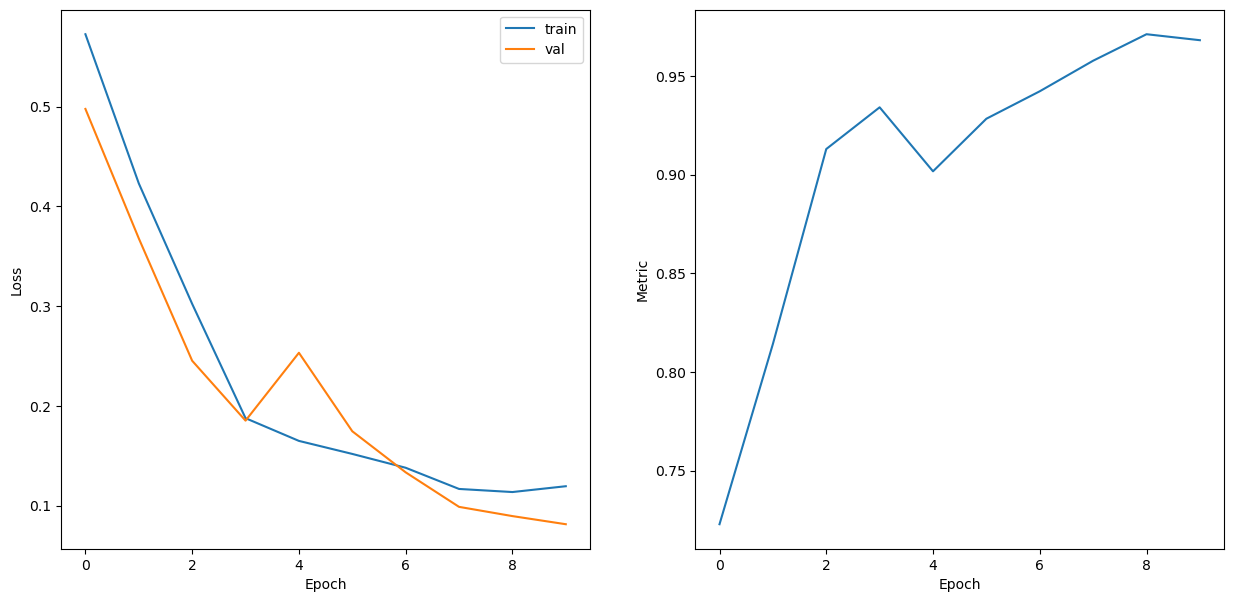

In [8]:
import IPython
import IPython.display
from sklearn.metrics import f1_score


EPOCHS = 10
resnet_1d = ResNet1d().to(device=device)
optimizer = torch.optim.Adam(resnet_1d.parameters())
criterion = torch.nn.BCELoss()


# mode - parameter that determines the method of calculating the loss and the metric
# average - parameter that determines the method of averaging the metric
def train(model,
          train_loader,
          val_loader,
          epochs,
          criterion,
          dtype,
          optimizer,
          metric,
          filename,
          scheduler=None,
          mode='binary', 
          average='binary'): 
    best_val_loss = np.inf
    epoch_train = []
    epoch_val = []
    epoch_metric = []
    for epoch in range(epochs):
        model.train()
        train_loss = []
        val_loss = []
        val_metric = []
        for x, y in train_loader:
            optimizer.zero_grad()
            out = model(x.to(device=device))
            loss = criterion(out, y.to(device=device, dtype=dtype))
            train_loss.append(loss.item())
            loss.backward()
            optimizer.step()
        epoch_train.append(sum(train_loss) / len(train_loader))
        model.eval()
        with torch.no_grad():
            for x, y in val_loader:
                out = model(x.to(device=device))
                loss = criterion(out, y.to(device=device, dtype=dtype))
                val_loss.append(loss.item())
                if mode == 'binary':
                    val_metric.append(metric(y, out.detach().cpu() > 0.5, average=average))
                else:
                    val_metric.append(metric(y, torch.argmax(out.detach().cpu(), dim=1), average=average))
        mean_val_loss = sum(val_loss) / len(val_loader)
        if mean_val_loss < best_val_loss:
            torch.save(model.state_dict(), filename)
        epoch_val.append(mean_val_loss)
        epoch_metric.append(sum(val_metric) / len(val_loader))
        if scheduler is not None:
            scheduler.step()        
        IPython.display.clear_output()
        fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15, 7))
        ax[0].plot(list(range(0, epoch+1)), epoch_train, label='train')
        ax[0].plot(list(range(0, epoch+1)), epoch_val, label='val')
        ax[0].legend()
        ax[0].set_xlabel('Epoch')
        ax[0].set_ylabel('Loss')
        ax[1].plot(list(range(0, epoch+1)), epoch_metric)
        ax[1].set_xlabel('Epoch')
        ax[1].set_ylabel('Metric')
        plt.show()


train(resnet_1d, train_loader, val_loader, EPOCHS, criterion, torch.float, optimizer, f1_score, 'best_1d.pt')

F1 = 0.97312529705211


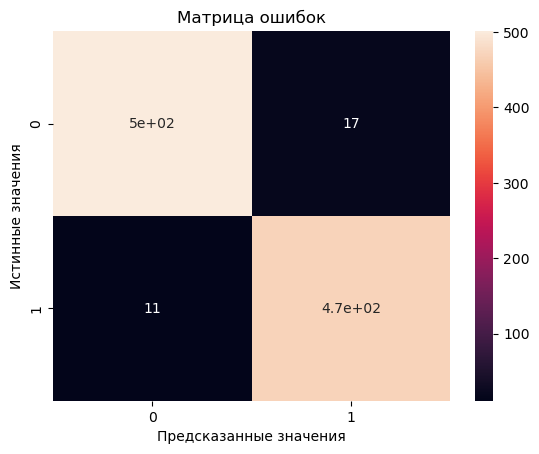

In [9]:
from sklearn.metrics import confusion_matrix
import seaborn as sns


best_resnet_1d = ResNet1d().to(device=device)
best_resnet_1d.load_state_dict(torch.load('best_1d.pt'))


# mode - parameter that determines the method of calculating the metric
# average - parameter that determines the method of averaging the metric
def mean_metric_on_test(model, metric, test_loader, mode='binary', average='binary'):
    metrics = []
    model.eval()
    with torch.no_grad():
        for x, y in test_loader:
            out = model(x.to(device))
            if mode == 'binary':
                metrics.append(metric(y, out.detach().cpu() > 0.5, average=average))
            else:
                metrics.append(metric(y, torch.argmax(out.detach().cpu(), dim=1), average=average))
    return sum(metrics) / len(test_loader)


# mode - parameter that determines the method of calculating the metric
def get_confusion_matrix(model, test_loader, mode='binary'):
    y_true = []
    y_pred = []
    model.eval()
    with torch.no_grad():
        for x, y in test_loader:
            y_true += y.tolist()
            out = model(x.to(device=device))
            if mode == 'binary':
                y_pred += (out.detach().cpu() > 0.5).tolist()
            else:
                y_pred += torch.argmax(out.detach().cpu(), dim=1).tolist()
    sns.heatmap(confusion_matrix(y_true, y_pred), annot=True)
    plt.ylabel('Истинные значения')
    plt.xlabel('Предсказанные значения')
    plt.title('Матрица ошибок')
    plt.show()


print(f'F1 = {mean_metric_on_test(best_resnet_1d, f1_score, test_loader)}')
get_confusion_matrix(best_resnet_1d, test_loader)

In [10]:
healthy_fft = '../data/processed_engine_1/0702 без перекосов фаза A.txt/ours_spectrogram'
fault_fft = [
    '../data/processed_engine_1/0702  межвитковые фазы A ток фазы А.txt/ours_spectrogram',
    '../data/processed_engine_1/20_01_1460_об_мин_с_дисбалансом_ротора.txt/ours_spectrogram',
    '../data/processed_engine_1/21 02 дисбаланс макс обороты 100%.txt/ours_spectrogram',
    '../data/processed_engine_1/0702  перекос фазы A ток фазы А.txt/ours_spectrogram',
    '../data/processed_engine_1/ВКЛ-ВЫКЛ нагрузка 100% 11 01.txt/ours_spectrogram',
    '../data/processed_engine_1/нагрузка 100% 11 01.txt/ours_spectrogram',
    '../data/processed_engine_1/холостой ход 11 01.txt/ours_spectrogram'
    ]

train_loader, val_loader, test_loader = get_binary_dataloaders(healthy_fft, fault_fft)

In [11]:
class ResNet2dLayer(torch.nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size_1, kernel_size_2, padding=0, stride=1):
        super().__init__()
        self.input = torch.nn.Sequential(
            torch.nn.Conv2d(in_channels=in_channels,
                            out_channels=in_channels,
                            kernel_size=kernel_size_1,
                            padding=padding,
                            stride=stride),
            torch.nn.BatchNorm2d(in_channels),
            torch.nn.ReLU(),
            torch.nn.Conv2d(in_channels=in_channels,
                            out_channels=out_channels,
                            kernel_size=kernel_size_1,
                            padding=padding,
                            stride=stride),
            torch.nn.BatchNorm2d(out_channels),
        )
        self.residual = torch.nn.Sequential(
            torch.nn.Conv2d(
                in_channels=in_channels,
                out_channels=out_channels,
                kernel_size=kernel_size_2,
                padding=padding,
                stride=stride
            )
        )
        self.activation = torch.nn.ReLU()

    def forward(self, x):
        return self.activation(self.input(x) + self.residual(x))


class ResNet2d(torch.nn.Module):
    def __init__(self, in_channels=1, out_features=1):
        super().__init__()
        self.seq  = torch.nn.Sequential(
            torch.nn.Conv2d(in_channels=in_channels,
                            out_channels=in_channels,
                            kernel_size=7,
                            stride=2),
            torch.nn.BatchNorm2d(in_channels),
            torch.nn.MaxPool2d(kernel_size=3),
            ResNet2dLayer(in_channels=in_channels,
                          out_channels=in_channels, 
                          kernel_size_1=3, 
                          kernel_size_2=5),
            ResNet2dLayer(in_channels=in_channels,
                          out_channels=2*in_channels, 
                          kernel_size_1=3, 
                          kernel_size_2=5),
            ResNet2dLayer(in_channels=2*in_channels, 
                          out_channels=2*in_channels, 
                          kernel_size_1=3, 
                          kernel_size_2=5),
            ResNet2dLayer(in_channels=2*in_channels, 
                          out_channels=4*in_channels,
                          kernel_size_1=3, 
                          kernel_size_2=5),
            ResNet2dLayer(in_channels=4*in_channels,
                          out_channels=4*in_channels, 
                          kernel_size_1=3, 
                          kernel_size_2=5),
            ResNet2dLayer(in_channels=4*in_channels, 
                          out_channels=8*in_channels, 
                          kernel_size_1=3, 
                          kernel_size_2=5),
            torch.nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.fc = torch.nn.Sequential(
            torch.nn.Linear(in_features=8*in_channels, out_features=out_features),
            torch.nn.Sigmoid()
        )

    def forward(self, x):
        out = self.fc(self.seq(x).squeeze()).squeeze()
        if x.size(0) == 1:
            out = out.unsqueeze(0)
        return out

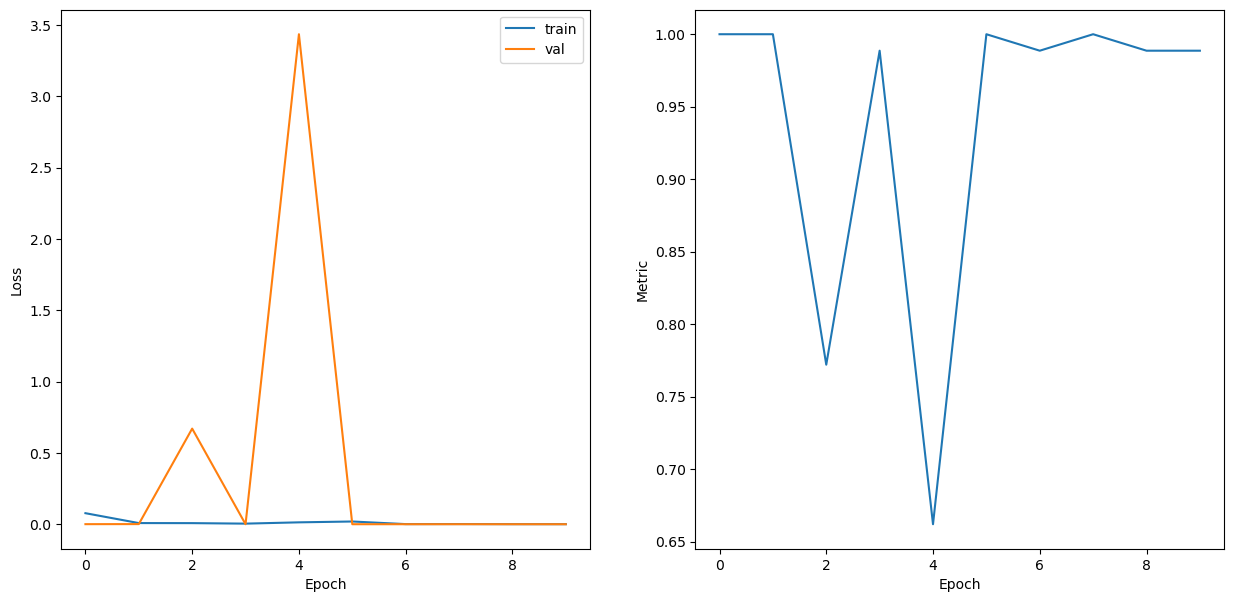

In [12]:
EPOCHS = 10
resnet_2d = ResNet2d().to(device=device)
optimizer = torch.optim.Adam(resnet_2d.parameters())
criterion = torch.nn.BCELoss()

train(resnet_2d, train_loader, val_loader, EPOCHS, criterion, torch.float, optimizer, f1_score, 'best_2d.pt')

F1 = 1.0


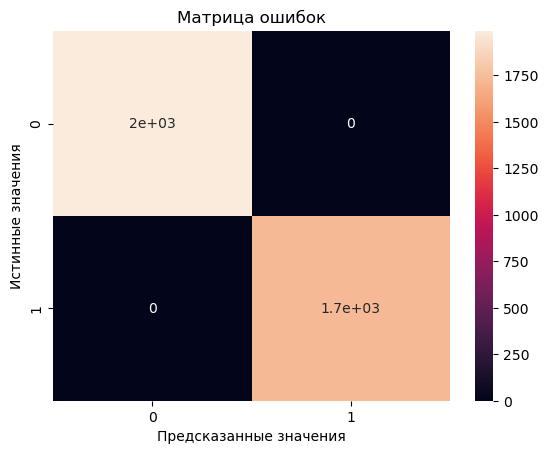

In [13]:
best_resnet_2d = ResNet2d().to(device=device)
best_resnet_2d.load_state_dict(torch.load('best_2d.pt'))

print(f'F1 = {mean_metric_on_test(best_resnet_2d, f1_score, test_loader)}')
get_confusion_matrix(best_resnet_2d, test_loader)

Попробуем многоклассовую классификацию.

In [14]:
signals_list = [
    '../data/processed_engine_1/0702 без перекосов фаза A.txt/ours_FFT',
    '../data/processed_engine_1/0702  межвитковые фазы A ток фазы А.txt/ours_FFT',
    '../data/processed_engine_1/20_01_1460_об_мин_с_дисбалансом_ротора.txt/ours_FFT',
    '../data/processed_engine_1/21 02 дисбаланс макс обороты 100%.txt/ours_FFT',
    '../data/processed_engine_1/0702  перекос фазы A ток фазы А.txt/ours_FFT',
    '../data/processed_engine_1/ВКЛ-ВЫКЛ нагрузка 100% 11 01.txt/ours_FFT',
    '../data/processed_engine_1/нагрузка 100% 11 01.txt/ours_FFT',
    '../data/processed_engine_1/холостой ход 11 01.txt/ours_FFT'
    ]

train_loader, val_loader, test_loader = get_multiclass_dataloaders(signals_list)

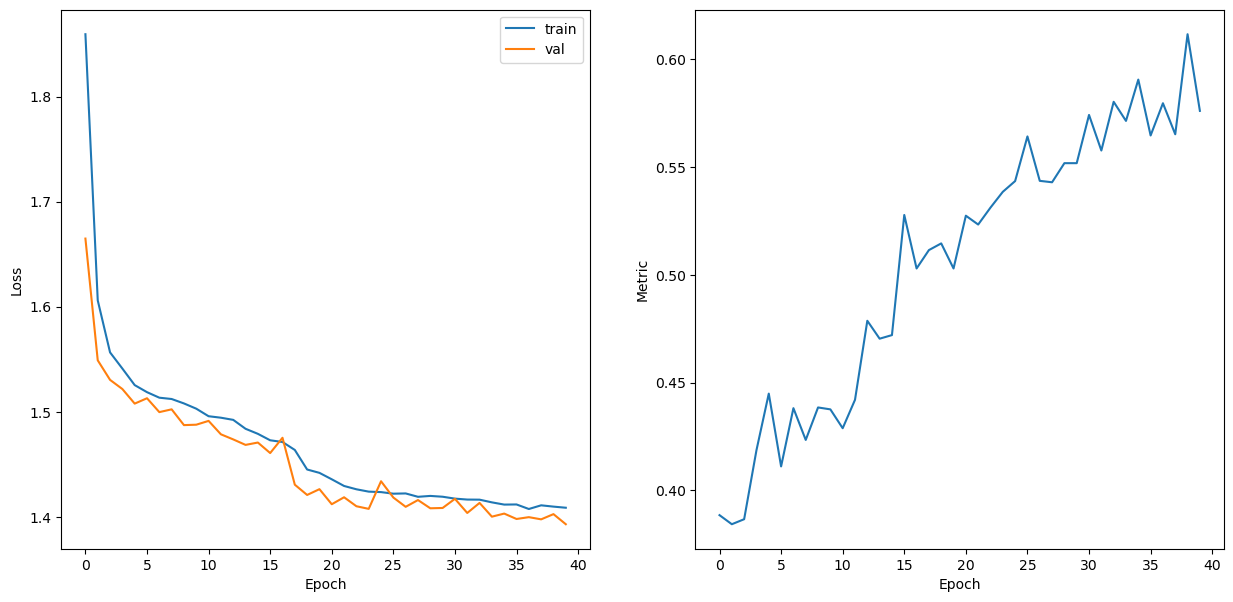

In [15]:
EPOCHS = 40
resnet_1d = ResNet1d(out_features=8).to(device=device)
optimizer = torch.optim.Adam(resnet_1d.parameters())
criterion = torch.nn.CrossEntropyLoss()

train(resnet_1d, train_loader, val_loader, EPOCHS, criterion, torch.long, optimizer, f1_score, 'best_1d_multiclass.pt', mode='multi', average='micro')

F1 = 0.56425


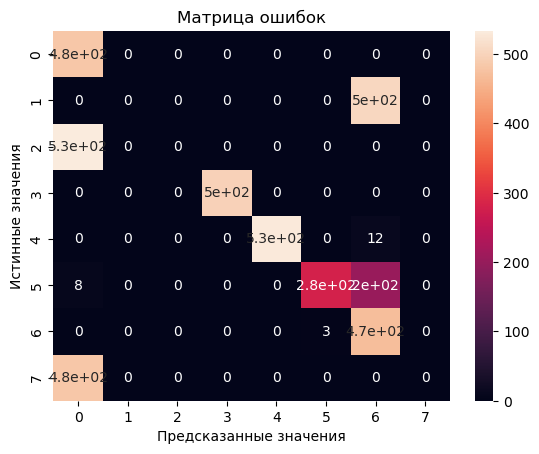

In [16]:
best_resnet_1d = ResNet1d(out_features=8).to(device=device)
best_resnet_1d.load_state_dict(torch.load('best_1d_multiclass.pt'))

mean_metric = mean_metric_on_test(best_resnet_1d, f1_score, test_loader, mode='multi', average='micro')
print(f'F1 = {mean_metric}')
get_confusion_matrix(best_resnet_1d, test_loader, mode='multi')

In [17]:
signals_list = [
    '../data/processed_engine_1/0702 без перекосов фаза A.txt/ours_spectrogram',
    '../data/processed_engine_1/0702  межвитковые фазы A ток фазы А.txt/ours_spectrogram',
    '../data/processed_engine_1/20_01_1460_об_мин_с_дисбалансом_ротора.txt/ours_spectrogram',
    '../data/processed_engine_1/21 02 дисбаланс макс обороты 100%.txt/ours_spectrogram',
    '../data/processed_engine_1/0702  перекос фазы A ток фазы А.txt/ours_spectrogram',
    '../data/processed_engine_1/ВКЛ-ВЫКЛ нагрузка 100% 11 01.txt/ours_spectrogram',
    '../data/processed_engine_1/нагрузка 100% 11 01.txt/ours_spectrogram',
    '../data/processed_engine_1/холостой ход 11 01.txt/ours_spectrogram'
    ]

train_loader, val_loader, test_loader = get_multiclass_dataloaders(signals_list, all_data_samples=2000)

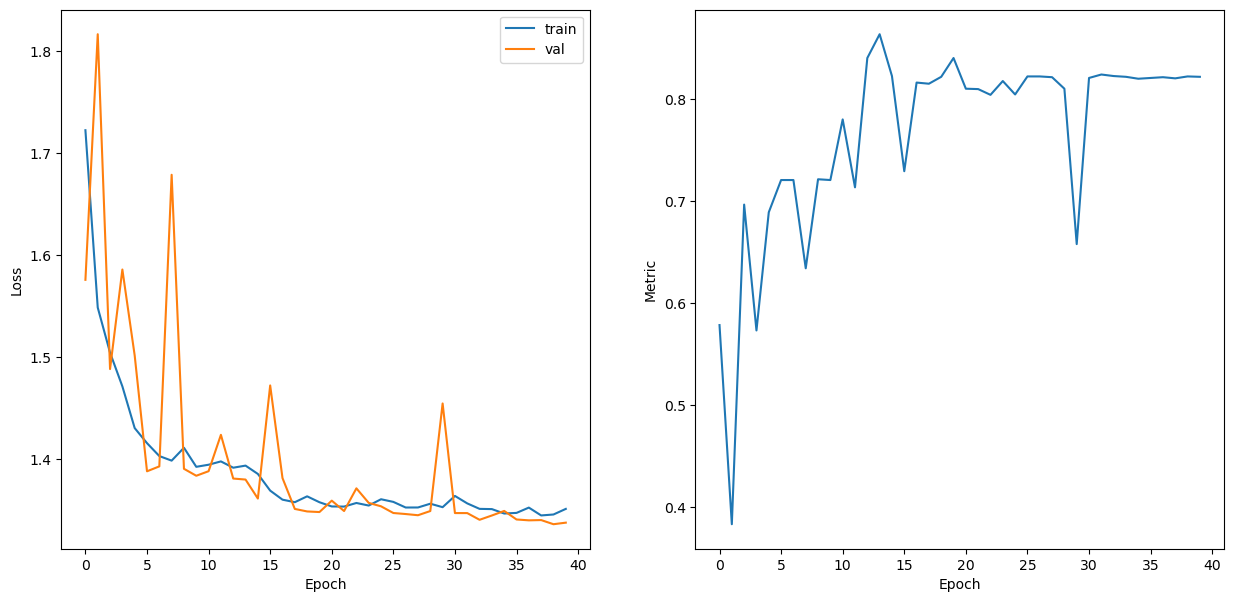

In [18]:
EPOCHS = 40
resnet_2d = ResNet2d(out_features=8).to(device=device)
optimizer = torch.optim.Adam(resnet_2d.parameters())
criterion = torch.nn.CrossEntropyLoss()

train(resnet_2d, train_loader, val_loader, EPOCHS, criterion, torch.long, optimizer, f1_score, 'best_2d_multiclass.pt', mode='multi', average='micro')

F1 = 0.8222537878787879


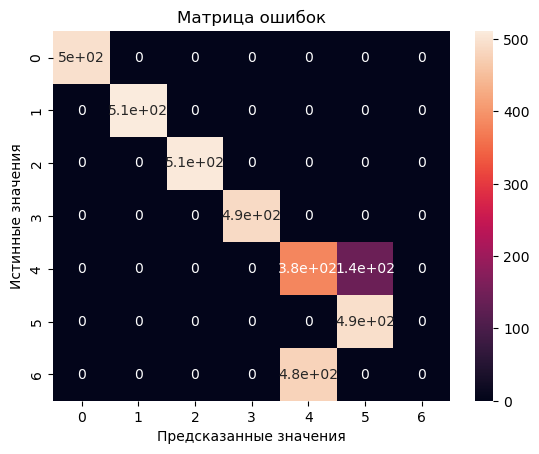

In [19]:
best_resnet_2d = ResNet2d(out_features=8).to(device=device)
best_resnet_2d.load_state_dict(torch.load('best_2d_multiclass.pt'))

mean_metric = mean_metric_on_test(best_resnet_2d, f1_score, test_loader, mode='multi', average='micro')
print(f'F1 = {mean_metric}')
get_confusion_matrix(best_resnet_2d, test_loader, mode='multi')

Теперь поделим сигналы в точном соответствии с дефектами и еще раз обучим нейросеть:

In [20]:
signals_list = [
    '../data/processed_engine_1/0702 без перекосов фаза A.txt/ours_FFT',
    '../data/processed_engine_1/0702  перекос фазы A ток фазы А.txt/ours_FFT',
    '../data/processed_engine_1/0702  межвитковые фазы A ток фазы А.txt/ours_FFT',
    '../data/processed_engine_1/20_01_1460_об_мин_с_дисбалансом_ротора.txt/ours_FFT',
    '../data/processed_engine_1/21 02 дисбаланс макс обороты 100%.txt/ours_FFT',
    '../data/processed_engine_1/ВКЛ-ВЫКЛ нагрузка 100% 11 01.txt/ours_FFT',
    '../data/processed_engine_1/нагрузка 100% 11 01.txt/ours_FFT',
    '../data/processed_engine_1/холостой ход 11 01.txt/ours_FFT'
    ]
label_match_list = [0, 0, 0, 1, 2, 3, 3, 3]
samples_count_list = [666, 666, 666, 2000, 2000, 666, 666, 666]

In [21]:
train_loader, val_loader, test_loader = get_manual_labeled_dataloaders(signals_list, label_match_list, samples_count_list)

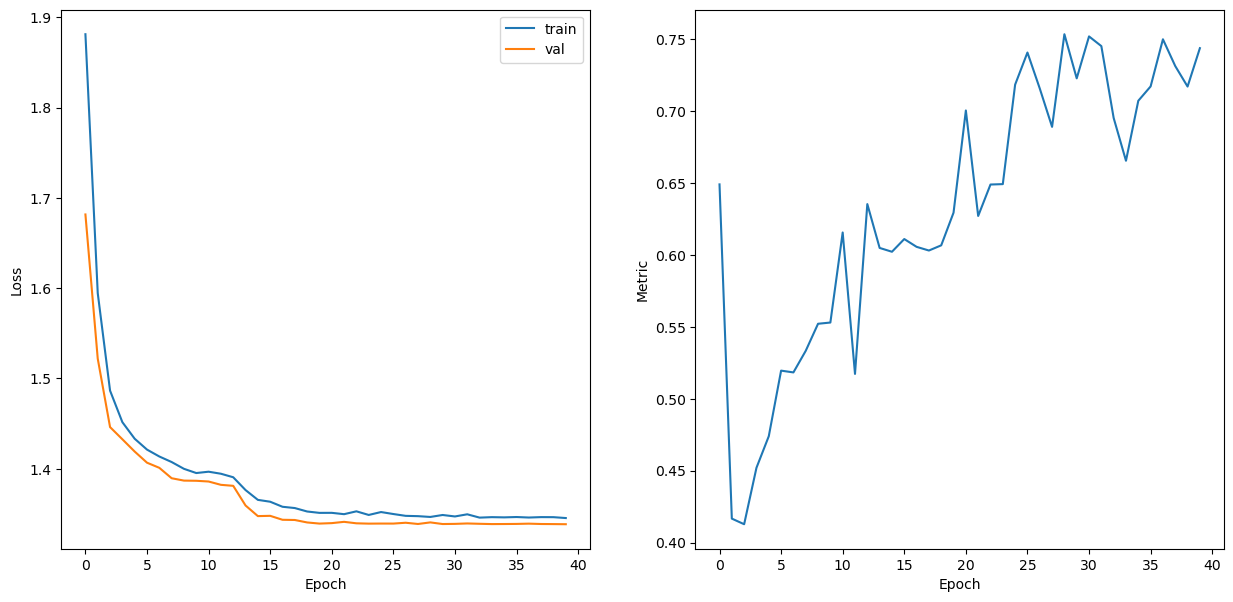

In [22]:
EPOCHS = 40
resnet_1d = ResNet1d(out_features=8).to(device=device)
optimizer = torch.optim.Adam(resnet_1d.parameters())
criterion = torch.nn.CrossEntropyLoss()

train(resnet_1d, train_loader, val_loader, EPOCHS, criterion, torch.long, optimizer, f1_score, 'best_1d_manual.pt', mode='multi', average='micro')

F1 = 0.7296957671957671


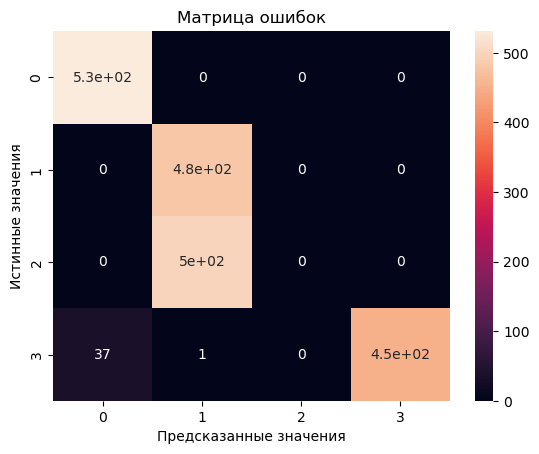

In [23]:
best_resnet_1d = ResNet1d(out_features=8).to(device=device)
best_resnet_1d.load_state_dict(torch.load('best_1d_manual.pt'))

mean_metric = mean_metric_on_test(best_resnet_1d, f1_score, test_loader, mode='multi', average='micro')
print(f'F1 = {mean_metric}')
get_confusion_matrix(best_resnet_1d, test_loader, mode='multi')

In [24]:
signals_list = [
    '../data/processed_engine_1/0702 без перекосов фаза A.txt/ours_spectrogram',
    '../data/processed_engine_1/0702  перекос фазы A ток фазы А.txt/ours_spectrogram',
    '../data/processed_engine_1/0702  межвитковые фазы A ток фазы А.txt/ours_spectrogram',
    '../data/processed_engine_1/20_01_1460_об_мин_с_дисбалансом_ротора.txt/ours_spectrogram',
    '../data/processed_engine_1/21 02 дисбаланс макс обороты 100%.txt/ours_spectrogram',
    '../data/processed_engine_1/ВКЛ-ВЫКЛ нагрузка 100% 11 01.txt/ours_spectrogram',
    '../data/processed_engine_1/нагрузка 100% 11 01.txt/ours_spectrogram',
    '../data/processed_engine_1/холостой ход 11 01.txt/ours_spectrogram'
    ]
label_match_list = [0, 0, 0, 1, 2, 3, 3, 3]
samples_count_list = [666, 666, 666, 2000, 2000, 666, 666, 666]

In [25]:
train_loader, val_loader, test_loader = get_manual_labeled_dataloaders(signals_list, label_match_list, samples_count_list)

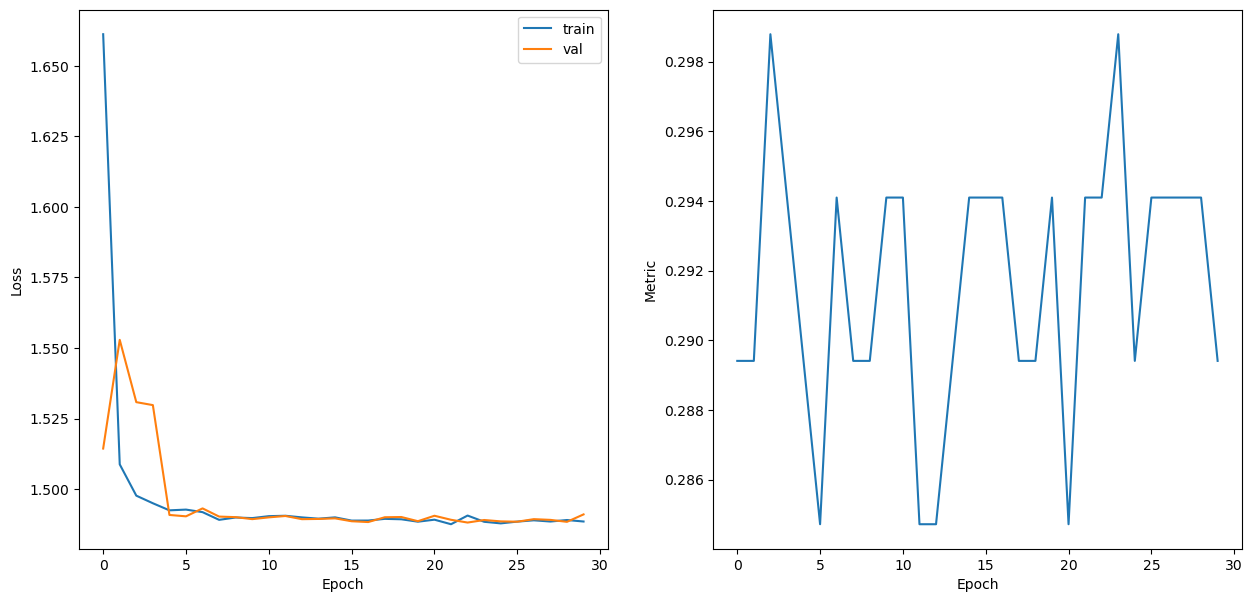

In [26]:
EPOCHS = 30
resnet_2d = ResNet2d(out_features=8).to(device=device)
optimizer = torch.optim.Adam(resnet_2d.parameters())
scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[4, 12, 24], gamma=0.1)
criterion = torch.nn.CrossEntropyLoss()

train(resnet_2d, 
      train_loader, 
      val_loader, 
      EPOCHS, 
      criterion, 
      torch.long, 
      optimizer, 
      f1_score, 
      'best_2d_manual.pt', 
      scheduler=scheduler,
      mode='multi', 
      average='micro')

F1 = 0.35217198581560283


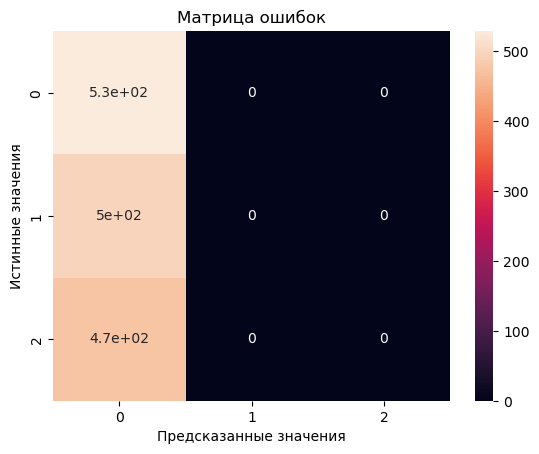

In [27]:
best_resnet_2d = ResNet2d(out_features=8).to(device=device)
best_resnet_2d.load_state_dict(torch.load('best_2d_manual.pt'))

mean_metric = mean_metric_on_test(best_resnet_2d, f1_score, test_loader, mode='multi', average='micro')
print(f'F1 = {mean_metric}')
get_confusion_matrix(best_resnet_2d, test_loader, mode='multi')

In [28]:
signals_list = [
    '../data/processed_engine_2/1st_load_0/1/1727783110/ours_FFT',
    '../data/processed_engine_2/1st_load_20/1/1727783630/ours_FFT',
    '../data/processed_engine_2/1st_load_40/1/1727784190/ours_FFT',
    '../data/processed_engine_2/1st_load_60/1/1727785030/ours_FFT',
    '../data/processed_engine_2/1st_load_80/1/1727785790/ours_FFT',
    '../data/processed_engine_2/1st_load_100/1/1727786490/ours_FFT',

    '../data/processed_engine_2/2nd_load_0/1/1727787950/ours_FFT',
    '../data/processed_engine_2/2nd_load_20/1/1727788510/ours_FFT',
    '../data/processed_engine_2/2nd_load_40/1/1727789090/ours_FFT',
    '../data/processed_engine_2/2nd_load_60/1/1727789712/ours_FFT',
    '../data/processed_engine_2/2nd_load_80/1/1727790230/ours_FFT',
    '../data/processed_engine_2/2ns_load_100/1/1727790870/ours_FFT',

    '../data/processed_engine_2/3rd_load_0/1/1727862102/ours_FFT',
    '../data/processed_engine_2/3rd_load_20/1/1727862702/ours_FFT',
    '../data/processed_engine_2/3rd_load_40/1/1727863242/ours_FFT',
    '../data/processed_engine_2/3rd_load_60/1/1727863902/ours_FFT',
    '../data/processed_engine_2/3rd_load_80/1/1727864502/ours_FFT',
    '../data/processed_engine_2/3rd_load_100/1/1727865162/ours_FFT',

    '../data/processed_engine_2/4th_load_60/1/1727935897/ours_FFT',
    '../data/processed_engine_2/4th_load_80/1/1727936637/ours_FFT',
    '../data/processed_engine_2/4th_load_100/1/1727937257/ours_FFT'
    ]
label_match_list = [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 3, 3, 3]
samples_count_list = [333 for _ in range(6)] + [333 for _ in range(6)] + [333 for _ in range(6)] + [666, 666, 666]

In [29]:
train_loader, val_loader, test_loader = get_manual_labeled_dataloaders(signals_list, label_match_list, samples_count_list)

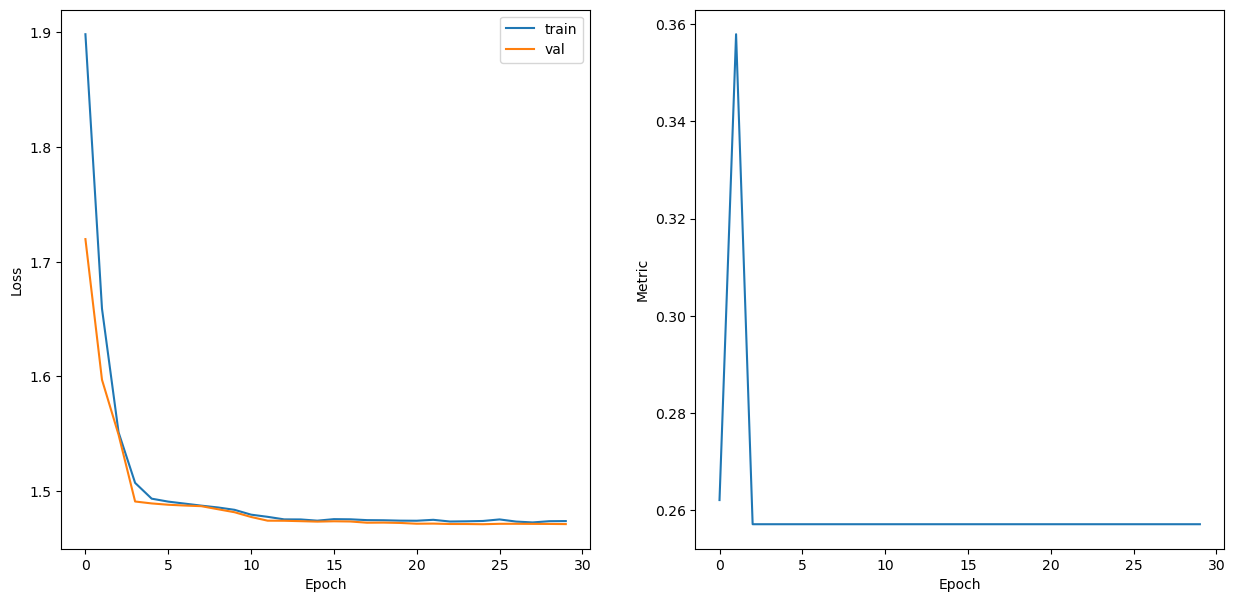

In [30]:
EPOCHS = 30
resnet_1d = ResNet1d(out_features=8).to(device=device)
optimizer = torch.optim.Adam(resnet_1d.parameters())
scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[4, 12, 24], gamma=0.1)
criterion = torch.nn.CrossEntropyLoss()

train(resnet_1d, 
      train_loader, 
      val_loader, 
      EPOCHS, 
      criterion, 
      torch.long, 
      optimizer, 
      f1_score, 
      'best_1d_manual.pt', 
      scheduler=scheduler,
      mode='multi', 
      average='micro')

F1 = 0.2603914447134786


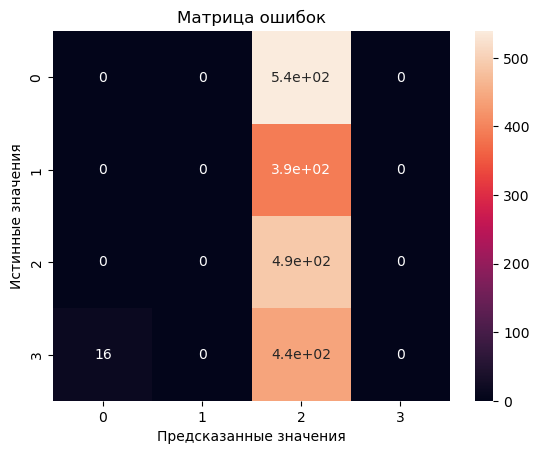

In [31]:
best_resnet_1d = ResNet1d(out_features=8).to(device=device)
best_resnet_1d.load_state_dict(torch.load('best_1d_manual.pt'))

mean_metric = mean_metric_on_test(best_resnet_1d, f1_score, test_loader, mode='multi', average='micro')
print(f'F1 = {mean_metric}')
get_confusion_matrix(best_resnet_1d, test_loader, mode='multi')

In [32]:
signals_list = [
    '../data/processed_engine_2/1st_load_0/1/1727783110/ours_spectrogram',
    '../data/processed_engine_2/1st_load_20/1/1727783630/ours_spectrogram',
    '../data/processed_engine_2/1st_load_40/1/1727784190/ours_spectrogram',
    '../data/processed_engine_2/1st_load_60/1/1727785030/ours_spectrogram',
    '../data/processed_engine_2/1st_load_80/1/1727785790/ours_spectrogram',
    '../data/processed_engine_2/1st_load_100/1/1727786490/ours_spectrogram',

    '../data/processed_engine_2/2nd_load_0/1/1727787950/ours_spectrogram',
    '../data/processed_engine_2/2nd_load_20/1/1727788510/ours_spectrogram',
    '../data/processed_engine_2/2nd_load_40/1/1727789090/ours_spectrogram',
    '../data/processed_engine_2/2nd_load_60/1/1727789712/ours_spectrogram',
    '../data/processed_engine_2/2nd_load_80/1/1727790230/ours_spectrogram',
    '../data/processed_engine_2/2ns_load_100/1/1727790870/ours_spectrogram',

    '../data/processed_engine_2/3rd_load_0/1/1727862102/ours_spectrogram',
    '../data/processed_engine_2/3rd_load_20/1/1727862702/ours_spectrogram',
    '../data/processed_engine_2/3rd_load_40/1/1727863242/ours_spectrogram',
    '../data/processed_engine_2/3rd_load_60/1/1727863902/ours_spectrogram',
    '../data/processed_engine_2/3rd_load_80/1/1727864502/ours_spectrogram',
    '../data/processed_engine_2/3rd_load_100/1/1727865162/ours_spectrogram',

    '../data/processed_engine_2/4th_load_60/1/1727935897/ours_spectrogram',
    '../data/processed_engine_2/4th_load_80/1/1727936637/ours_spectrogram',
    '../data/processed_engine_2/4th_load_100/1/1727937257/ours_spectrogram'
    ]
label_match_list = [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 3, 3, 3]
samples_count_list = [333 for _ in range(6)] + [333 for _ in range(6)] + [333 for _ in range(6)] + [666, 666, 666]

In [33]:
train_loader, val_loader, test_loader = get_manual_labeled_dataloaders(signals_list, label_match_list, samples_count_list)

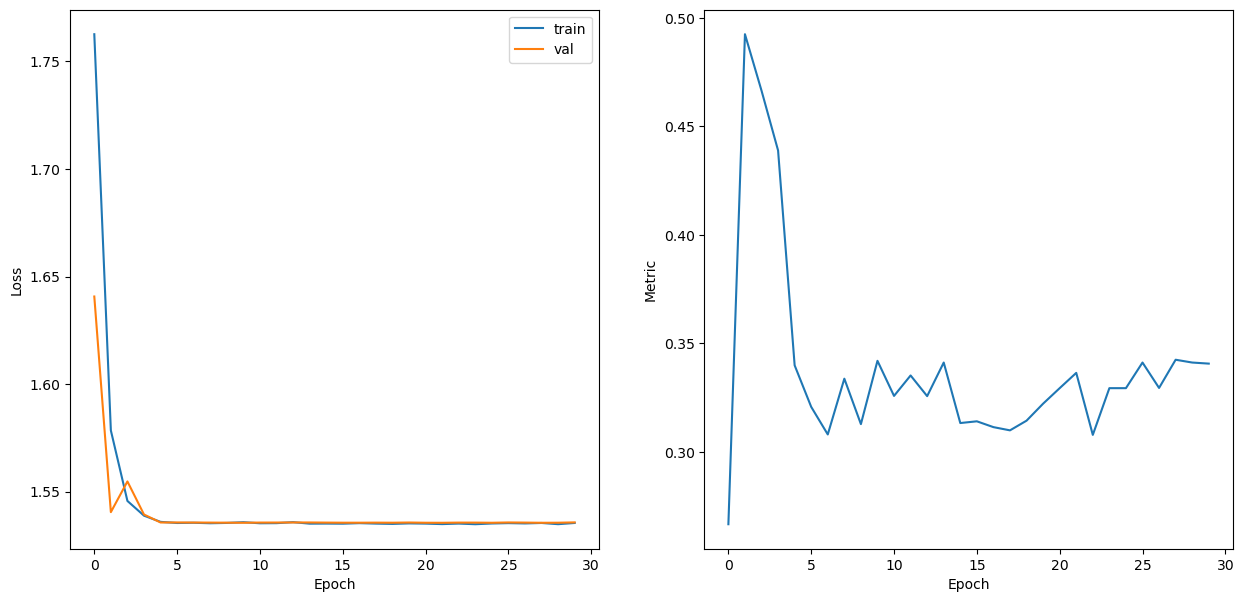

In [35]:
EPOCHS = 30
resnet_2d = ResNet2d(out_features=8).to(device=device)
optimizer = torch.optim.Adam(resnet_2d.parameters())
scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[4, 12, 24], gamma=0.1)
criterion = torch.nn.CrossEntropyLoss()

train(resnet_2d, 
      train_loader, 
      val_loader, 
      EPOCHS, 
      criterion, 
      torch.long, 
      optimizer, 
      f1_score, 
      'best_2d_manual.pt', 
      scheduler=scheduler,
      mode='multi', 
      average='micro')

F1 = 0.34035493827160496


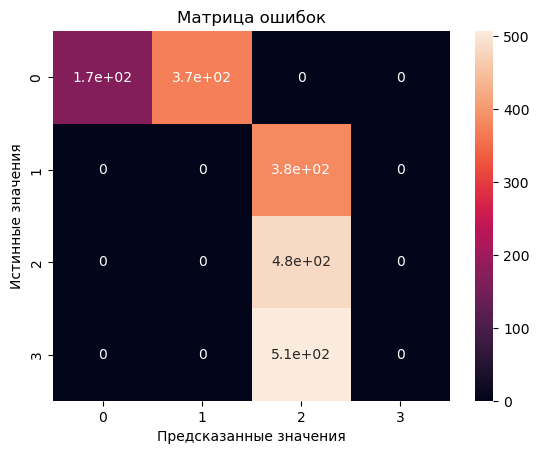

In [36]:
best_resnet_2d = ResNet2d(out_features=8).to(device=device)
best_resnet_2d.load_state_dict(torch.load('best_2d_manual.pt'))

mean_metric = mean_metric_on_test(best_resnet_2d, f1_score, test_loader, mode='multi', average='micro')
print(f'F1 = {mean_metric}')
get_confusion_matrix(best_resnet_2d, test_loader, mode='multi')

Теперь попробуем обучиться на трехмерных спектрограммах.

In [37]:
class FFTDataset3D(FFTDataset):
    def __init__(self, channel_1_files, labels):
        self.data = []
        self.labels = []
        for channel_1_file in channel_1_files:
            channel_1_data = np.load(channel_1_file)
            channel_2_file = ['2' if part == '1' else part for part in channel_1_file.parts]
            channel_2_data = np.load(Path(*channel_2_file))
            channel_3_file = ['3' if part == '1' else part for part in channel_1_file.parts]
            channel_3_data = np.load(Path(*channel_3_file))
            full_data = np.zeros((3, channel_1_data.shape[0], channel_1_data.shape[1]))
            full_data[0, :, :] = channel_1_data
            full_data[1, :, :] = channel_2_data
            full_data[2, :, :] = channel_3_data
            self.data.append(torch.FloatTensor(full_data))
        self.labels = labels


def get_manual_labeled_dataloaders_3d(folders_list: List[str],
                                      labels_match_list: List[int],
                                      samples_count_list: List[int],
                                      test_size: float = 0.25,
                                      seed: int = 42,
                                      batch_size = 32) -> List[DataLoader]:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    fft_list = []
    labels_list = []
    for folder, label, samples_count in zip(folders_list, labels_match_list, samples_count_list):
        class_list = list(Path(folder).rglob('*.npy'))
        if samples_count is not None:
            class_list = class_list[:samples_count]
        fft_list += class_list
        labels_list += [label for _ in range(len(class_list))]
    Xtrain, Xtest, ytrain, ytest = train_test_split(fft_list, labels_list, random_state=seed, test_size=test_size)
    Xtrain, Xval, ytrain, yval = train_test_split(Xtrain, ytrain, random_state=seed, test_size=test_size)
    train_dataset = FFTDataset3D(Xtrain, ytrain)
    val_dataset = FFTDataset3D(Xval, yval)
    test_dataset = FFTDataset3D(Xtest, ytest)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    return train_loader, val_loader, test_loader

In [38]:
train_loader, val_loader, test_loader = get_manual_labeled_dataloaders_3d(signals_list, label_match_list, samples_count_list)

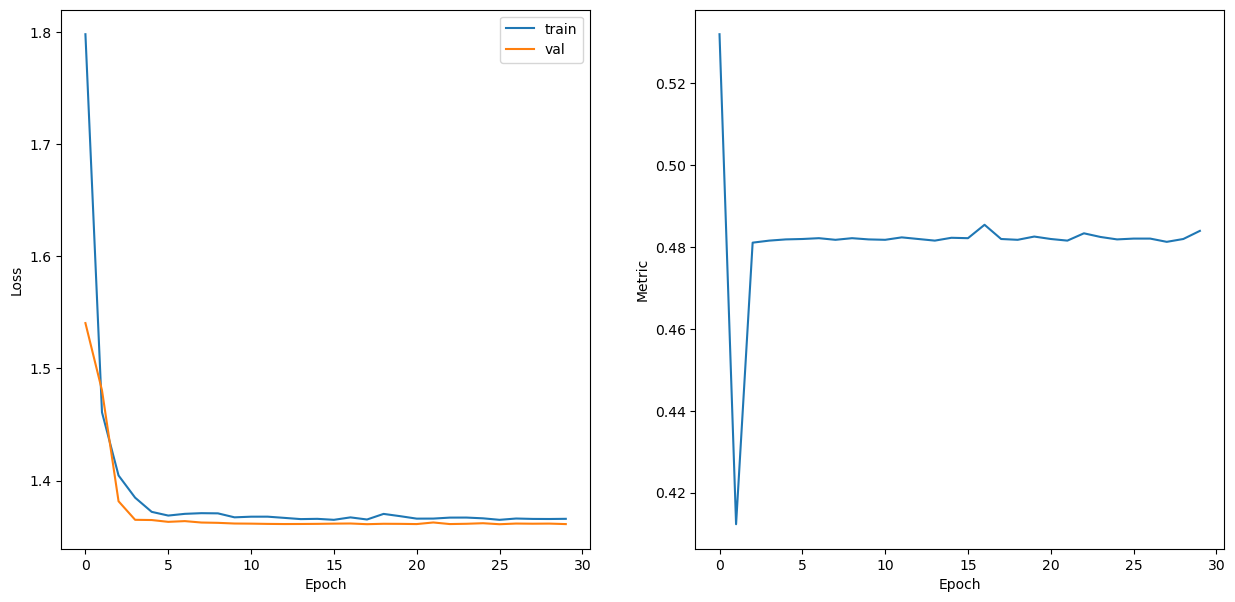

In [39]:
EPOCHS = 30
resnet_2d = ResNet2d(in_channels=3, out_features=8).to(device=device)
optimizer = torch.optim.Adam(resnet_2d.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[4, 12, 24], gamma=0.1)
criterion = torch.nn.CrossEntropyLoss()

train(resnet_2d, 
      train_loader, 
      val_loader, 
      EPOCHS, 
      criterion, 
      torch.long, 
      optimizer, 
      f1_score, 
      'best_2d_manual.pt',
      scheduler=scheduler, 
      mode='multi', 
      average='micro')

F1 = 0.45522762345679013


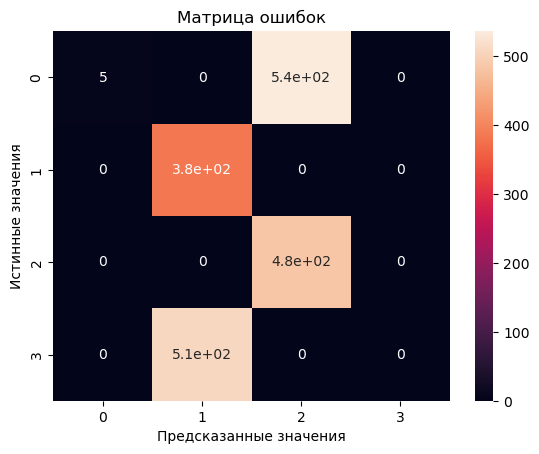

In [40]:
best_resnet_2d = ResNet2d(in_channels=3, out_features=8).to(device=device)
best_resnet_2d.load_state_dict(torch.load('best_2d_manual.pt'))

mean_metric = mean_metric_on_test(best_resnet_2d, f1_score, test_loader, mode='multi', average='micro')
print(f'F1 = {mean_metric}')
get_confusion_matrix(best_resnet_2d, test_loader, mode='multi')